# Concept Drift Detection and Adaptive Retraining Pipeline

Real-world data is dynamic. Unlike static academic datasets, production data streams evolve over time due to seasonal patterns, changes in user behavior, macroeconomic shifts, or system changes. When the data distribution changes, machine learning models trained on older data suffer from **model decay** (performance degradation).

This notebook demonstrates:
1. **Covariate Shift / Data Drift**: Change in the distribution of input features $P(X)$.
2. **Concept Drift**: Change in the relationship between input features and target variables $P(Y|X)$.
3. **Drift Detection**: Utilizing statistical methods such as the **Population Stability Index (PSI)** and **Kolmogorov-Smirnov (KS) Test**.
4. **Adaptive Retraining**: Automatically triggering a retraining pipeline when drift is detected to restore model performance.

--- 
## 1. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 18
})
print("Libraries successfully imported!")

Libraries successfully imported!


--- 
## 2. Simulate Temporal Data Stream
We will generate 10 batches (representing 10 sequential time periods, like months) of loan default data.
- **Batches 1-3 (Baseline)**: Stable distributions and decision boundary.
- **Batches 4-6 (Covariate Shift)**: Economic conditions worsen. Average borrower income drops, debt-to-income increases, but the lending policy / relationship determining default stays the same.
- **Batches 7-10 (Concept Drift)**: The underlying relationship shifts (lending policies tighten, making previously safe borrowers default at a higher rate).

In [2]:
def generate_synthetic_data(n_samples_per_batch=1000, n_batches=10, random_seed=42):
    np.random.seed(random_seed)
    batches = []
    
    # Baseline coefficients for default calculation
    w_intercept = -1.0
    w_dti = 5.0
    w_credit = -4.0
    w_income = -1.5
    
    for batch_id in range(1, n_batches + 1):
        age = np.random.randint(20, 70, size=n_samples_per_batch)
        
        # 1. Baseline Period (Batches 1-3)
        if batch_id <= 3:
            income = np.random.normal(60000, 15000, size=n_samples_per_batch)
            credit_score = np.random.normal(680, 50, size=n_samples_per_batch)
            debt_to_income = np.random.beta(2, 5, size=n_samples_per_batch)
            
        # 2. Covariate Shift Period (Batches 4-6)
        elif 4 <= batch_id <= 6:
            income = np.random.normal(50000, 12000, size=n_samples_per_batch)
            credit_score = np.random.normal(640, 60, size=n_samples_per_batch)
            debt_to_income = np.random.beta(3, 4, size=n_samples_per_batch)
            
        # 3. Concept Drift Period (Batches 7-10)
        else:
            income = np.random.normal(52000, 12000, size=n_samples_per_batch)
            credit_score = np.random.normal(650, 55, size=n_samples_per_batch)
            debt_to_income = np.random.beta(3, 4, size=n_samples_per_batch)
            
            # Shift coefficients
            w_intercept = 0.5
            w_dti = 7.0
            w_credit = -5.0
            w_income = -1.0
            
        income = np.clip(income, 10000, 150000)
        credit_score = np.clip(credit_score, 300, 850)
        debt_to_income = np.clip(debt_to_income, 0.0, 1.0)
        
        # Scale features to compute logits
        norm_income = (income - 60000) / 15000
        norm_credit = (credit_score - 680) / 50
        norm_dti = (debt_to_income - 0.25) / 0.15
        
        logits = w_intercept + (w_dti * norm_dti) + (w_credit * norm_credit) + (w_income * norm_income)
        probs = 1 / (1 + np.exp(-logits))
        default = np.random.binomial(1, probs)
        
        df = pd.DataFrame({
            'age': age,
            'income': income,
            'debt_to_income': debt_to_income,
            'credit_score': credit_score,
            'default': default,
            'batch_id': batch_id
        })
        batches.append(df)
        
    return pd.concat(batches, ignore_index=True)

data = generate_synthetic_data()
data.groupby('batch_id').mean()

,age,income,debt_to_income,credit_score,default
batch_id,,,,,
1,44.830,61224.682294,0.278759,680.929335,0.479
2,45.097,59613.383129,0.279680,680.544510,0.468
3,44.846,60208.600531,0.286923,679.519350,0.496
4,44.236,49609.564879,0.418903,640.940405,0.867
5,44.510,49382.815550,0.419573,639.713764,0.874
6,44.459,49743.529113,0.425710,639.450790,0.879
7,45.275,52795.951681,0.428835,650.548041,0.887
8,44.327,52485.215437,0.428648,651.173673,0.879
9,44.236,51341.877305,0.436611,649.413989,0.899


--- 
## 3. Drift Detection Implementation
We will implement two statistical methods for drift detection:
1. **Population Stability Index (PSI)**: Measures how much a variable's distribution has changed between two samples. A PSI >= 0.25 indicates significant shift.
2. **Kolmogorov-Smirnov (KS) Test**: A non-parametric test comparing cumulative distributions. A p-value < 0.05 indicates statistical difference.

In [3]:
def calculate_psi(reference, target, num_bins=10, epsilon=1e-4):
    reference = np.array(reference)
    target = np.array(target)
    
    percentiles = np.linspace(0, 100, num_bins + 1)
    bin_edges = np.percentile(reference, percentiles)
    
    bin_edges[0] -= epsilon
    bin_edges[-1] += epsilon
    
    ref_counts, _ = np.histogram(reference, bins=bin_edges)
    target_counts, _ = np.histogram(target, bins=bin_edges)
    
    ref_pct = ref_counts / len(reference)
    target_pct = target_counts / len(target)
    
    ref_pct = np.where(ref_pct == 0, epsilon, ref_pct)
    target_pct = np.where(target_pct == 0, epsilon, target_pct)
    
    ref_pct = ref_pct / np.sum(ref_pct)
    target_pct = target_pct / np.sum(target_pct)
    
    psi_value = np.sum((target_pct - ref_pct) * np.log(target_pct / ref_pct))
    return psi_value

def calculate_ks_test(reference, target):
    ks_stat, p_value = ks_2samp(reference, target)
    return ks_stat, p_value, p_value < 0.05

def check_feature_drift(reference_df, target_df, features, psi_threshold=0.25):
    drift_report = {}
    for feature in features:
        ref_data = reference_df[feature].dropna()
        tgt_data = target_df[feature].dropna()
        
        psi_val = calculate_psi(ref_data, tgt_data)
        ks_stat, p_val, ks_drift = calculate_ks_test(ref_data, tgt_data)
        psi_drift = psi_val >= psi_threshold
        
        drift_report[feature] = {
            'psi_value': psi_val,
            'psi_drift_detected': bool(psi_drift),
            'ks_statistic': ks_stat,
            'ks_p_value': p_val,
            'ks_drift_detected': bool(ks_drift),
            'overall_drift_detected': bool(psi_drift or ks_drift)
        }
    return drift_report

--- 
## 4. Run Monitoring & Adaptive Retraining Pipeline
Let's train a model on Batch 1 (our baseline) and monitor it sequentially.

In [4]:
features = ['age', 'income', 'debt_to_income', 'credit_score']
target = 'default'

# Batch 1 baseline setup
batch_1 = data[data['batch_id'] == 1]
X_train_baseline = batch_1[features]
y_train_baseline = batch_1[target]

scaler = StandardScaler()
X_train_baseline_scaled = scaler.fit_transform(X_train_baseline)

# 1. Static model (will NOT be retrained)
model_static = RandomForestClassifier(n_estimators=100, random_state=42)
model_static.fit(X_train_baseline_scaled, y_train_baseline)

# 2. Adaptive model (will be retrained when drift is detected)
model_adaptive = RandomForestClassifier(n_estimators=100, random_state=42)
model_adaptive.fit(X_train_baseline_scaled, y_train_baseline)

history = []
reference_df = batch_1

print(f"{'Batch':<6} | {'PSI (DTI)':<10} | {'KS p-val (DTI)':<15} | {'Acc (Static)':<12} | {'Acc (Adapt)':<12} | {'Retrained?'}")
print("-" * 80)

for batch_id in range(2, 11):
    batch_df = data[data['batch_id'] == batch_id]
    X_batch = batch_df[features]
    y_batch = batch_df[target]
    X_batch_scaled = scaler.transform(X_batch)
    
    # 1. Detect drift
    drift_report = check_feature_drift(reference_df, batch_df, features)
    drift_features = [f for f, r in drift_report.items() if r['psi_drift_detected']]
    drift_detected = len(drift_features) > 0
    
    dti_psi = drift_report['debt_to_income']['psi_value']
    dti_p_val = drift_report['debt_to_income']['ks_p_value']
    
    # 2. Performance of static model
    y_pred_static = model_static.predict(X_batch_scaled)
    acc_static = accuracy_score(y_batch, y_pred_static)
    f1_static = f1_score(y_batch, y_pred_static)
    
    # 3. Performance of adaptive model (pre-retraining evaluation)
    y_pred_adaptive_pre = model_adaptive.predict(X_batch_scaled)
    acc_adaptive_pre = accuracy_score(y_batch, y_pred_adaptive_pre)
    f1_adaptive_pre = f1_score(y_batch, y_pred_adaptive_pre)
    
    # 4. Action Trigger
    retrained = False
    if drift_detected:
        # Retrain on current batch
        X_train_new_scaled = scaler.transform(X_batch)
        model_adaptive = RandomForestClassifier(n_estimators=100, random_state=42)
        model_adaptive.fit(X_train_new_scaled, y_batch)
        
        y_pred_adaptive_post = model_adaptive.predict(X_batch_scaled)
        acc_adaptive = accuracy_score(y_batch, y_pred_adaptive_post)
        f1_adaptive = f1_score(y_batch, y_pred_adaptive_post)
        retrained = True
    else:
        acc_adaptive = acc_adaptive_pre
        f1_adaptive = f1_adaptive_pre
        
    print(f"{batch_id:<6} | {dti_psi:<10.3f} | {dti_p_val:<15.3e} | {acc_static:<12.3f} | {acc_adaptive:<12.3f} | {str(retrained):<10}")
    
    history.append({
        'batch_id': batch_id,
        'dti_psi': dti_psi,
        'dti_p_val': dti_p_val,
        'acc_static': acc_static,
        'acc_adaptive': acc_adaptive,
        'f1_static': f1_static,
        'f1_adaptive': f1_adaptive,
        'drift_detected': drift_detected,
        'retrained': retrained
    })

history_df = pd.DataFrame(history)

Batch  | PSI (DTI)  | KS p-val (DTI)  | Acc (Static) | Acc (Adapt)  | Retrained?
--------------------------------------------------------------------------------
2      | 0.016      | 3.701e-01       | 0.897        | 0.897        | False     
3      | 0.020      | 5.363e-01       | 0.915        | 0.915        | False     
4      | 0.776      | 2.070e-47       | 0.959        | 1.000        | True      
5      | 0.654      | 7.793e-43       | 0.946        | 1.000        | True      
6      | 0.752      | 3.101e-52       | 0.947        | 1.000        | True      
7      | 0.762      | 4.649e-55       | 0.935        | 1.000        | True      
8      | 0.763      | 1.763e-53       | 0.945        | 1.000        | True      
9      | 0.899      | 2.435e-56       | 0.961        | 1.000        | True      
10     | 0.679      | 2.070e-47       | 0.941        | 1.000        | True      


--- 
## 5. Visualizations & Analysis

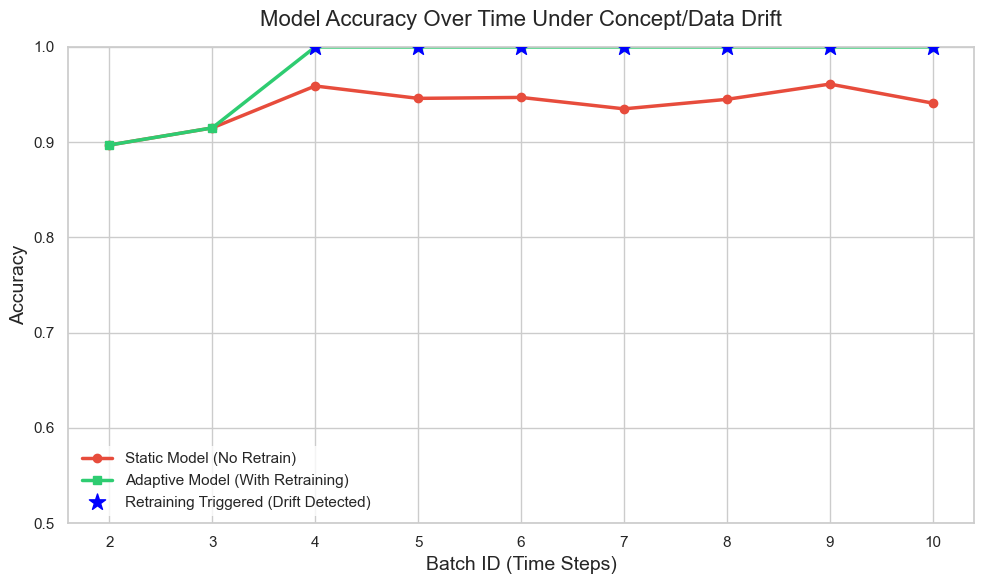

In [5]:
# Plot Accuracy Comparison
plt.figure(figsize=(10, 6))
plt.plot(history_df['batch_id'], history_df['acc_static'], marker='o', linewidth=2.5, label='Static Model (No Retrain)', color='#e74c3c')
plt.plot(history_df['batch_id'], history_df['acc_adaptive'], marker='s', linewidth=2.5, label='Adaptive Model (With Retraining)', color='#2ecc71')

retrain_pts = history_df[history_df['retrained'] == True]
if not retrain_pts.empty:
    plt.scatter(retrain_pts['batch_id'], retrain_pts['acc_adaptive'], color='blue', s=150, zorder=5, 
                label='Retraining Triggered (Drift Detected)', marker='*')

plt.title("Model Accuracy Over Time Under Concept/Data Drift", pad=15)
plt.xlabel("Batch ID (Time Steps)")
plt.ylabel("Accuracy")
plt.xticks(range(2, 11))
plt.ylim(0.5, 1.0)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

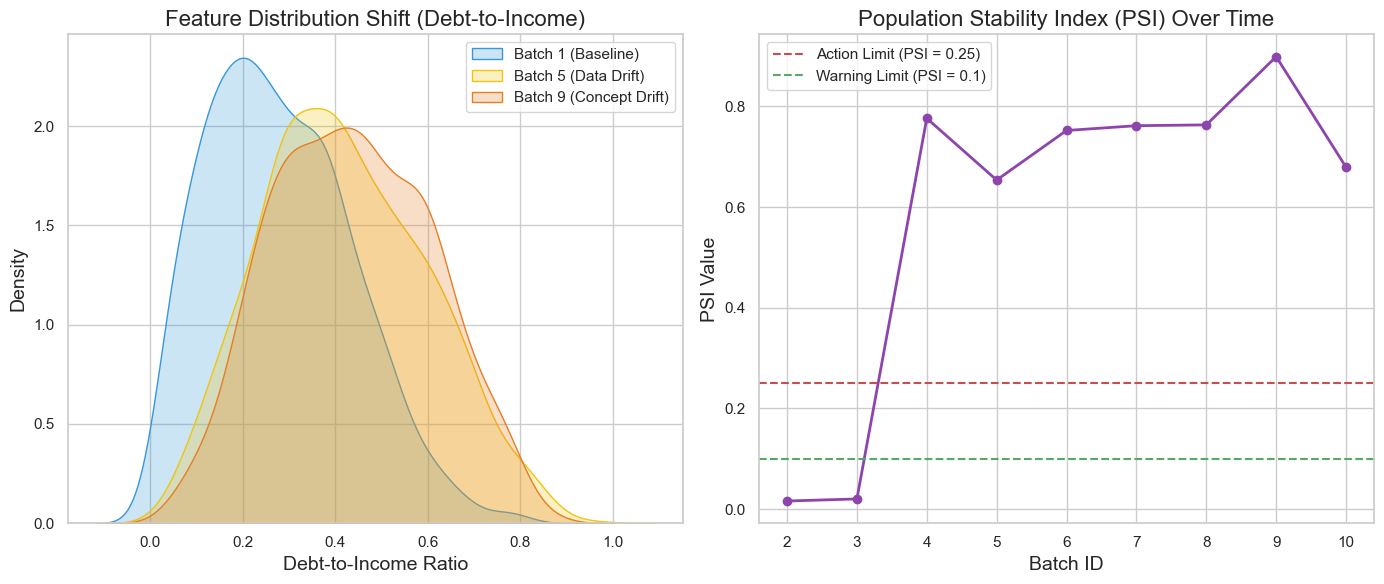

In [6]:
# Plot feature distribution shift and PSI
plt.figure(figsize=(14, 6))

# Distribution density
plt.subplot(1, 2, 1)
sns.kdeplot(data[data['batch_id'] == 1]['debt_to_income'], label='Batch 1 (Baseline)', fill=True, color='#3498db')
sns.kdeplot(data[data['batch_id'] == 5]['debt_to_income'], label='Batch 5 (Data Drift)', fill=True, color='#f1c40f')
sns.kdeplot(data[data['batch_id'] == 9]['debt_to_income'], label='Batch 9 (Concept Drift)', fill=True, color='#e67e22')
plt.title("Feature Distribution Shift (Debt-to-Income)")
plt.xlabel("Debt-to-Income Ratio")
plt.legend(frameon=True)

# PSI plot
plt.subplot(1, 2, 2)
plt.plot(history_df['batch_id'], history_df['dti_psi'], marker='o', color='#8e44ad', linewidth=2)
plt.axhline(y=0.25, color='r', linestyle='--', label='Action Limit (PSI = 0.25)')
plt.axhline(y=0.1, color='g', linestyle='--', label='Warning Limit (PSI = 0.1)')
plt.title("Population Stability Index (PSI) Over Time")
plt.xlabel("Batch ID")
plt.ylabel("PSI Value")
plt.xticks(range(2, 11))
plt.legend(frameon=True)

plt.tight_layout()
plt.show()